# AICE-Style Practice: Seoul Food Delivery (Regression)
이 문제세트는 공개 AICE 샘플과 **유사한 흐름**으로 구성되었지만, **완전히 새로운 데이터셋**을 사용합니다.

### 데이터
- `food_delivery_seoul.csv` : 주문 단위의 배달 기록
- `traffic_events.csv` : 동일 `OrderID` 기준의 교차 신호등 수

### 목표(Target)
- `Delivery_Time_Minutes` (분) 예측

### 권장 절차(문항 1~14)
임포트 → 읽기/머지 → 시각화(countplot, jointplot) → 이상치 제거 → 결측 처리 → 불필요 컬럼 삭제 → 원-핫 인코딩 → 스케일링 → 의사결정나무/랜덤포레스트 → MAE 비교 → 간단 MLP 회귀 → 학습곡선 시각화


## 1) scikit-learn 임포트

In [1]:
## 여기에 답안코드를 작성하세요.
import sklearn as sk

## 2) pandas 임포트

In [2]:
## 여기에 답안코드를 작성하세요.
import pandas as pd

## 3) 데이터 읽고 merge (inner) → df

In [3]:
df_main = pd.read_csv('food_delivery_seoul.csv')
df_traffic = pd.read_csv('traffic_events.csv')
df = pd.merge(df_main, df_traffic, on='OrderID', how='inner')
df.head()

,OrderID,Time_Order_Placed,Time_Order_Delivered,Distance_km,Delivery_Time_Minutes,Avg_Speed_kmh,Region1,Region2,Weekday,Hour,Day,PaymentMethod,CourierType,Num_Items,Tip_Amount,Traffic_Level,Num_Traffic_Lights
0,OD5641095040,15:24:06,15:50:28.786221,3.343,26.3798,9.2445,서울특별시,마포구,5,15,22,Card,Bike,4,1.41,4,11.0
1,OD0277345011,16:38:02,16:59:00.238847,3.485,20.9706,23.5761,서울특별시,동작구,5,16,8,Cash,Bike,1,3.46,3,19.0
2,OD4917557307,05:57:37,06:11:21.305448,1.729,13.7384,16.7848,서울특별시,종로구,5,5,1,AppPay,Bike,3,3.52,2,10.0
3,OD5389201855,13:00:22,13:16:28.404800,3.669,16.1067,27.2761,경기도,용인시 수지구,6,13,30,AppPay,Car,3,2.94,2,21.0
4,OD1985308402,13:40:28,13:53:53.425886,3.222,13.4238,30.3559,서울특별시,강서구,4,13,14,AppPay,Car,4,3.64,3,11.0


In [5]:
## 여기에 답안코드를 작성하세요.
df_main = pd.read_csv('food_delivery_seoul.csv')
df_traffic = pd.read_csv('traffic_events.csv')
df = pd.merge(df_main, df_traffic, on='OrderID', how='inner')
df.head()

,OrderID,Time_Order_Placed,Time_Order_Delivered,Distance_km,Delivery_Time_Minutes,Avg_Speed_kmh,Region1,Region2,Weekday,Hour,Day,PaymentMethod,CourierType,Num_Items,Tip_Amount,Traffic_Level,Num_Traffic_Lights
0,OD5641095040,15:24:06,15:50:28.786221,3.343,26.3798,9.2445,서울특별시,마포구,5,15,22,Card,Bike,4,1.41,4,11.0
1,OD0277345011,16:38:02,16:59:00.238847,3.485,20.9706,23.5761,서울특별시,동작구,5,16,8,Cash,Bike,1,3.46,3,19.0
2,OD4917557307,05:57:37,06:11:21.305448,1.729,13.7384,16.7848,서울특별시,종로구,5,5,1,AppPay,Bike,3,3.52,2,10.0
3,OD5389201855,13:00:22,13:16:28.404800,3.669,16.1067,27.2761,경기도,용인시 수지구,6,13,30,AppPay,Car,3,2.94,2,21.0
4,OD1985308402,13:40:28,13:53:53.425886,3.222,13.4238,30.3559,서울특별시,강서구,4,13,14,AppPay,Car,4,3.64,3,11.0


다음 셀을 먼저 실행하세요(한글 폰트 지정)

In [9]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
plt.rc('font', family='NanumGothicCoding')

## 4) Region1 분포 countplot + '-' 제거
- 그래프를 보고 4지선다 중 **틀린 보기 번호**를 `답안04`에 저장하세요 (예: `답안04 = 2`)

findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
C:\Users\bdh99\anaconda3\envs\ten\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bdh99\anaconda3\envs\ten\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bdh99\anaconda3\envs\ten\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bdh99\anaconda3\envs\ten\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bdh99\anaconda3\envs\ten\lib\site-packages\IPython\core\pylabtools.

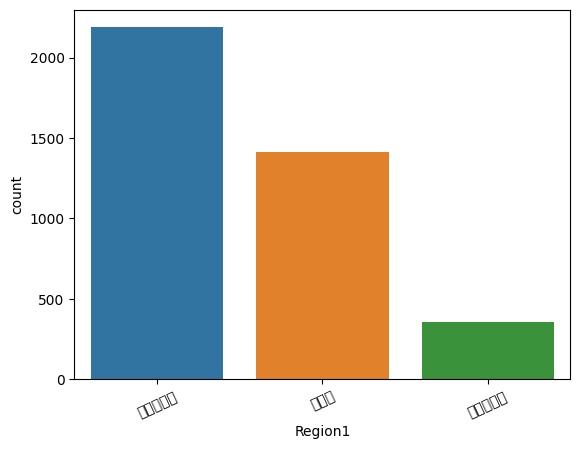

In [10]:
## 여기에 답안코드를 작성하세요.
import seaborn as sns
sns.countplot(data=df, x='Region1')
plt.xticks(rotation=25)
plt.show()
# '-' 제거
df = df[df['Region1']!='-'].copy()
답안04 = None

## 5) jointplot: Distance_km vs Delivery_Time_Minutes

findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.


findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not found.
findfont: Font family 'NanumGothicCoding' not 

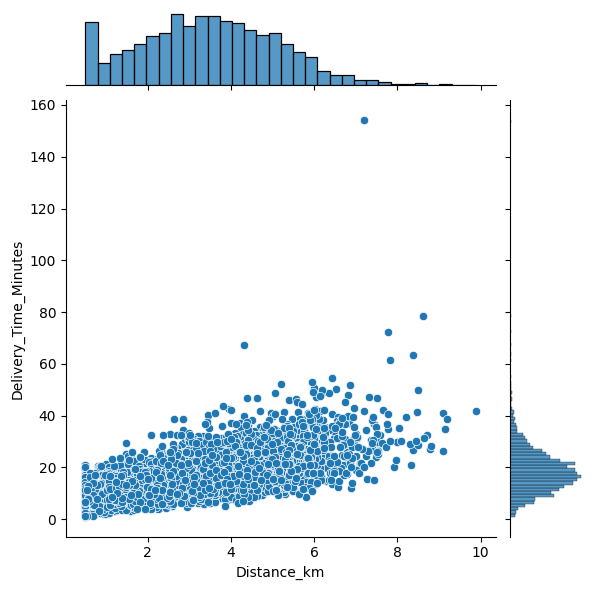

In [11]:
## 여기에 답안코드를 작성하세요.
import seaborn as sns
sns.jointplot(data=df, x='Distance_km', y='Delivery_Time_Minutes')

## 6) 이상치 제거 + 'OrderID' 컬럼 삭제 → df_temp
- 기준: `Avg_Speed_kmh >= 120` 는 이상치로 간주하여 제거

In [12]:
## 여기에 답안코드를 작성하세요.
df_temp = df[df['Avg_Speed_kmh'] < 120].copy()
df_temp = df_temp.drop(columns=['OrderID'])
df_temp.head()

,Time_Order_Placed,Time_Order_Delivered,Distance_km,Delivery_Time_Minutes,Avg_Speed_kmh,Region1,Region2,Weekday,Hour,Day,PaymentMethod,CourierType,Num_Items,Tip_Amount,Traffic_Level,Num_Traffic_Lights
0,15:24:06,15:50:28.786221,3.343,26.3798,9.2445,서울특별시,마포구,5,15,22,Card,Bike,4,1.41,4,11.0
1,16:38:02,16:59:00.238847,3.485,20.9706,23.5761,서울특별시,동작구,5,16,8,Cash,Bike,1,3.46,3,19.0
2,05:57:37,06:11:21.305448,1.729,13.7384,16.7848,서울특별시,종로구,5,5,1,AppPay,Bike,3,3.52,2,10.0
3,13:00:22,13:16:28.404800,3.669,16.1067,27.2761,경기도,용인시 수지구,6,13,30,AppPay,Car,3,2.94,2,21.0
4,13:40:28,13:53:53.425886,3.222,13.4238,30.3559,서울특별시,강서구,4,13,14,AppPay,Car,4,3.64,3,11.0


## 7) 결측치 확인/제거 → df_na, 결측 총개수 `답안07` 저장

In [16]:
## 여기에 답안코드를 작성하세요.
na_cnt = df_temp.isnull().sum().sum()
df_na = df_temp.dropna().copy()
답안07 = na_cnt
답안07

18

## 8) 불필요 시간 컬럼 삭제 → df_del
- `Time_Order_Placed`, `Time_Order_Delivered`

In [17]:
## 여기에 답안코드를 작성하세요.
to_drop = ['Time_Order_Placed','Time_Order_Delivered']
df_del = df_na.drop(columns=to_drop, errors='ignore').copy()
df_del.head()

,Distance_km,Delivery_Time_Minutes,Avg_Speed_kmh,Region1,Region2,Weekday,Hour,Day,PaymentMethod,CourierType,Num_Items,Tip_Amount,Traffic_Level,Num_Traffic_Lights
0,3.343,26.3798,9.2445,서울특별시,마포구,5,15,22,Card,Bike,4,1.41,4,11.0
1,3.485,20.9706,23.5761,서울특별시,동작구,5,16,8,Cash,Bike,1,3.46,3,19.0
2,1.729,13.7384,16.7848,서울특별시,종로구,5,5,1,AppPay,Bike,3,3.52,2,10.0
3,3.669,16.1067,27.2761,경기도,용인시 수지구,6,13,30,AppPay,Car,3,2.94,2,21.0
4,3.222,13.4238,30.3559,서울특별시,강서구,4,13,14,AppPay,Car,4,3.64,3,11.0


## 9) 범주형 전체 원-핫 인코딩 → df_preset

In [18]:
## 여기에 답안코드를 작성하세요.
obj_cols = df_del.select_dtypes(include='object').columns.tolist()
df_preset = pd.get_dummies(df_del, columns=obj_cols)
df_preset.head()

,Distance_km,Delivery_Time_Minutes,Avg_Speed_kmh,Weekday,Hour,Day,Num_Items,Tip_Amount,Traffic_Level,Num_Traffic_Lights,...,Region2_은평구,Region2_종로구,Region2_중구,Region2_평택시,PaymentMethod_AppPay,PaymentMethod_Card,PaymentMethod_Cash,CourierType_Bike,CourierType_Car,CourierType_Scooter
0,3.343,26.3798,9.2445,5,15,22,4,1.41,4,11.0,...,0,0,0,0,0,1,0,1,0,0
1,3.485,20.9706,23.5761,5,16,8,1,3.46,3,19.0,...,0,0,0,0,0,0,1,1,0,0
2,1.729,13.7384,16.7848,5,5,1,3,3.52,2,10.0,...,0,1,0,0,1,0,0,1,0,0
3,3.669,16.1067,27.2761,6,13,30,3,2.94,2,21.0,...,0,0,0,0,1,0,0,0,1,0
4,3.222,13.4238,30.3559,4,13,14,4,3.64,3,11.0,...,0,0,0,0,1,0,0,0,1,0


## 10) train/valid 분리 + RobustScaler

In [21]:
## 여기에 답안코드를 작성하세요.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
X = df_preset.drop('Delivery_Time_Minutes', axis=1).values
y = df_preset['Delivery_Time_Minutes'].values
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
rs = RobustScaler()
X_train = rs.fit_transform(X_train)
X_valid = rs.transform(X_valid)

## 11) DecisionTree & RandomForest 학습

In [22]:
## 여기에 답안코드를 작성하세요.
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
dt = DecisionTreeRegressor(max_depth=6, min_samples_split=4, random_state=120)
rf = RandomForestRegressor(max_depth=6, min_samples_split=4, random_state=120)
dt.fit(X_train, y_train); rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,6
,min_samples_split,4
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 12) MAE 비교 → `답안12` ('randomforest' 또는 'decisiontree')

In [23]:
## 여기에 답안코드를 작성하세요.
from sklearn.metrics import mean_absolute_error
y_pred_dt = dt.predict(X_valid); y_pred_rf = rf.predict(X_valid)
dt_mae = mean_absolute_error(y_valid, y_pred_dt)
rf_mae = mean_absolute_error(y_valid, y_pred_rf)
답안12 = 'randomforest' if rf_mae < dt_mae else 'decisiontree'
dt_mae, rf_mae, 답안12

(4.1713577605072425, 3.903305751186405, 'randomforest')

TensorFlow 셀을 먼저 실행하세요

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(7)

## 13) 간단 MLP 회귀 학습 → `history` 저장

In [ ]:
## 여기에 답안코드를 작성하세요.
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'), Dropout(0.2),
    Dense(16, activation='relu'), Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mse'])
history = model.fit(X_train, y_train, epochs=25, batch_size=32,
                    validation_data=(X_valid, y_valid), verbose=0)
list(history.history.keys())

## 14) 학습/검증 MSE 시각화

In [ ]:
## 여기에 답안코드를 작성하세요.
import matplotlib.pyplot as plt
plt.plot(history.history['mse']); plt.plot(history.history['val_mse'])
plt.title('Model MSE'); plt.xlabel('Epochs'); plt.ylabel('MSE');
plt.legend(['mse','val_mse']); plt.show()